## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [1]:
import pandas as pd
import numpy as np 


# Your Phase 1 solution to the problem goes here.
#Part 1
## Question 1
print("""Question 1:
The difference is whether the variable is quantitative or categorical. 
We use regression if the target variable is quantitative. 
It is used if we want to predict a numerical value. If a target variable is categorical, 
however, we use classification and that would help predict the class an observation should" 
go in.""")

##Question 2
print("""Question 2 
A confusion table is helpful for gauging the accuracy of a model. It compares the actual class 
labels with those that were predicted by a classification model. 
It is also useful for showing what classes are usually predicted well by a model, 
and which ones it tends to confuse.""")

##Question 3
print("""Question 3:
The SSE quantifies the total squared difference between the values that a model predicted and 
the actual values. If the value is lower, then the model generally did a better job predicting 
values. """)

##Question 4
print("""Question 4: 
If a model is too close to training data, and thus underperforms on new data, that is called 
overfitting, as it fits the training data too closely. Underfitting, on the other hand, is 
when a model is too simple and was not trained well enough to stop patterns in the data, 
thus also making it not a great predictor.""")

##Question 5
print("""Question 5:
A model can miss observations during training, so splitting the data can help us observe those 
things it missed. It gives a more clear picture and estimate of how accurately the model can 
generalize new data. This assistance in choosing the right k value that will neither overfit 
nor underfit.""")

##Question 6
print("""Question 6
A prediction label is easy to interpret since it is only one classification, but it can hide the 
uncertainty in a model, making it potentially unreliable. Probability distributions are more 
difficult to interpret, but their strength is that they can show how the model performs with 
and supports all possible classes, so we can have more confident predictions. """)

Question 1:
The difference is whether the variable is quantitative or categorical. 
We use regression if the target variable is quantitative. 
It is used if we want to predict a numerical value. If a target variable is categorical, 
however, we use classification and that would help predict the class an observation should" 
go in.
Question 2 
A confusion table is helpful for gauging the accuracy of a model. It compares the actual class 
labels with those that were predicted by a classification model. 
It is also useful for showing what classes are usually predicted well by a model, 
and which ones it tends to confuse.
Question 3:
The SSE quantifies the total squared difference between the values that a model predicted and 
the actual values. If the value is lower, then the model generally did a better job predicting 
values. 
Question 4: 
If a model is too close to training data, and thus underperforms on new data, that is called 
overfitting, as it fits the training data too closely. 

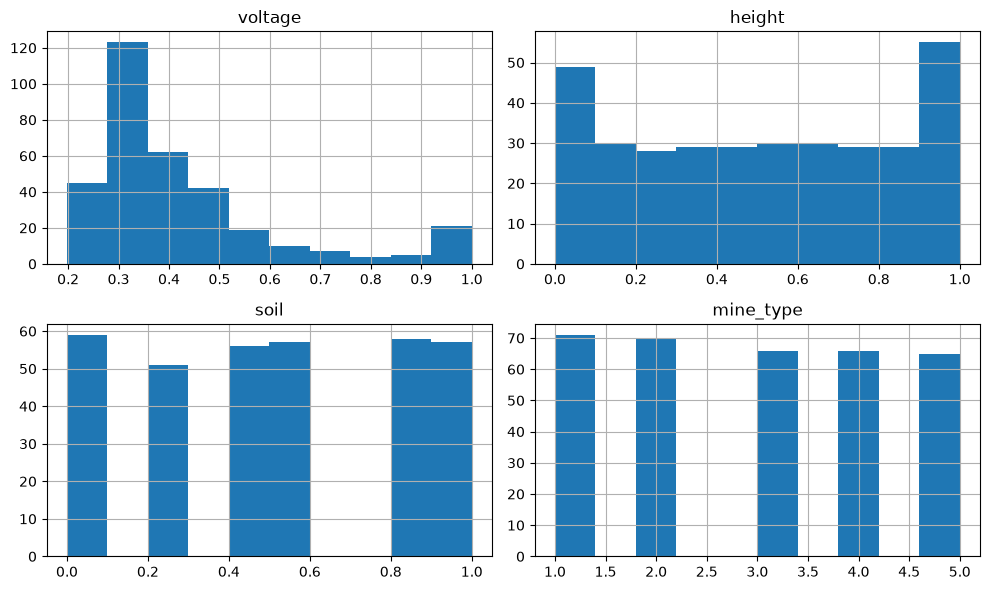

Best k is: 2
Most accurate is: 0.40828402366863903


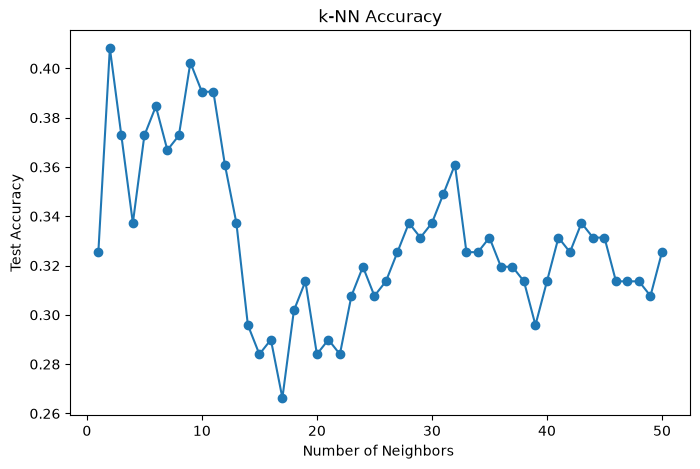

          Predicted 1  Predicted 2  Predicted 3  Predicted 4  Predicted 5
Actual 1           23            0           11            4            1
Actual 2            0           27            1            3            0
Actual 3           11            1           13            7            2
Actual 4           13            5            7            5            2
Actual 5           10            1           12            9            1
Accuracy: 0.40828402366863903
The model performed quite poorly, with an accuracy of approximately 40.8 percent, 
even when using an optimal k value of 2. Therefore, using solely this model to make predictions 
is not something I would advise. In looking at the confusion table, however, there are some 
aspects in which the model is more useful than others. For instance, it correctly classified 27 
of 31 of Type 2 mines, whereas it only correctly guessed 5 out of 32 Type 4 mines. So, the model 
does potentially serve a purpose in prediction, but it sho

In [ ]:
#Part 2
#import necessary packages 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt


#question 1 - load data and do some EDA
mines = pd.read_csv("data/land_mines.csv")
##examine data
mines.head()
mines.shape
mines.info
mines.describe
#look at target variable, mine_type, and add proportions
mines["mine_type"].value_counts().sort_index()
mines["mine_type"].value_counts(normalize=True).sort_index()
#missing values?
mines.isna().sum()
#visualize it
mines.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

#quesion 2 - 50/50 split 
#divide x and y and plit them
X = mines[["voltage", "height", "soil"]]
y = mines["mine_type"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=1
)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#question 3 - fit a kNN model with k=1
#test k 
k_values = range(1, 51)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

#optinal k?
best_accuracy = max(accuracies)
best_k = k_values[accuracies.index(best_accuracy)]

print("Best k is:", best_k)
print("Most accurate is:", best_accuracy)
#map it 
plt.figure(figsize=(8, 5))
#this k is what we will use for the confusion matrix

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("Number of Neighbors ")
plt.ylabel("Test Accuracy")
plt.title("k-NN Accuracy")

plt.show()

#quesiton 4 - confusion matrix for best k
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
#clean it up
cm_table = pd.DataFrame(
    cm,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=["Predicted 1", "Predicted 2", "Predicted 3", "Predicted 4", "Predicted 5"]
)
print(cm_table)
#accuracy?
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#question 5 - how someone should use this model? things to keep in mind
print("""The model performed quite poorly, with an accuracy of approximately 40.8 percent, 
even when using an optimal k value of 2. Therefore, using solely this model to make predictions 
is not something I would advise. In looking at the confusion table, however, there are some 
aspects in which the model is more useful than others. For instance, it correctly classified 27 
of 31 of Type 2 mines, whereas it only correctly guessed 5 out of 32 Type 4 mines. So, the model 
does potentially serve a purpose in prediction, but it should only be used in tandem with other 
models. What this tells us is that using a singular model is not the best approach for predictions, 
and that analysts should consider the Types that tend to perform particularly poorly when interpreting a 
prediction model’s projections. """)



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]